**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 3: Neural Networks*

# Identification

Name: Kaitlyn Wong<br/>
Student Number: 300201087

Name: Sooriya Radhakrishnan<br/>
Student Number: 300175667

## 1. Exploratory Analysis

### Loading the dataset

A custom dataset has been created for this assignment. It has been made available on a public GitHub repository:

- [github.com/turcotte/csi4106-f24/tree/main/assignments-data/a3](https://github.com/turcotte/csi4106-f24/tree/main/assignments-data/a3)

Access and read the dataset directly from this GitHub repository in your Jupyter notebook.

You can use this code cell for you import statements and other initializations.

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate
import tensorflow as tf
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, classification_report


In [3]:
source_url = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a3'

dataset_train = pd.read_csv(f'{source_url}/cb513_train.csv', header=None)
dataset_valid = pd.read_csv(f'{source_url}/cb513_valid.csv', header=None)
dataset_test = pd.read_csv(f'{source_url}/cb513_test.csv', header=None)

print(dataset_train.head())

   0       1       2       3       4       5       6       7       8    \
0    2  0.0000  0.0556  0.0000  0.0556  0.1111  0.0000  0.0556  0.0000   
1    2  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
2    2  0.1905  0.0000  0.3333  0.0000  0.0000  0.0000  0.0000  0.0000   
3    2  0.0225  0.0000  0.0112  0.1348  0.0000  0.0112  0.1348  0.0112   
4    2  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   

      9    ...     453     454     455     456     457     458  459     460  \
0  0.0000  ...  0.1667  0.2222  0.0000  0.0000  0.1667  0.0000  0.0  0.0000   
1  0.0000  ...  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0  0.0000   
2  0.2857  ...  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0  0.1905   
3  0.1685  ...  0.0000  0.0787  0.0674  0.0112  0.0225  0.1573  0.0  0.0225   
4  0.0000  ...  0.0000  0.0000  0.0000  0.6667  0.0000  0.0000  0.0  0.0000   

     461  462  
0  0.000  0.0  
1  0.000  0.0  
2  0.381  0.0  
3  0.000  0.0  


### Data Pre-Processing

2. **Shuffling the Rows**:

    - Since examples are generated by sliding a window across each protein sequence, most adjacent examples originate from the same protein and share 20 positions. To mitigate the potential negative impact on model training, the initial step involves shuffling the **rows** of the data matrix.

In [4]:
dataset_train = dataset_train.sample(frac=1, random_state=42)
dataset_valid = dataset_valid.sample(frac=1, random_state=42)
dataset_test = dataset_test.sample(frac=1, random_state=42)

print(dataset_train.head())


       0       1    2       3       4       5       6    7       8       9    \
644      0  0.1667  0.0  0.2500  0.0833  0.0000  0.0000  0.0  0.0000  0.0000   
50314    2  0.1461  0.0  0.0112  0.0000  0.0337  0.0225  0.0  0.0337  0.0112   
5325     0  0.0000  0.0  0.0000  0.0000  0.1250  0.0000  0.0  0.0000  0.5000   
35749    2  0.0000  0.0  0.0000  0.0000  0.2000  0.0000  0.0  0.0000  0.0000   
4805     0  0.0000  0.0  0.0000  0.0000  0.1000  0.0000  0.0  0.4000  0.0000   

       ...     453     454     455     456  457  458  459   460  461  462  
644    ...  0.0000  0.0833  0.0000  0.0000  0.0  0.0  0.0  0.00  0.0  0.0  
50314  ...  0.0112  0.3034  0.3596  0.0225  0.0  0.0  0.0  0.00  0.0  0.0  
5325   ...  0.0000  0.0000  0.0000  0.1250  0.0  0.0  0.0  0.25  0.0  0.0  
35749  ...  0.0000  0.0000  0.0000  0.0000  0.0  0.2  0.0  0.00  0.0  0.0  
4805   ...  0.0000  0.2000  0.1000  0.1000  0.0  0.1  0.0  0.00  0.0  0.0  

[5 rows x 463 columns]


3. **Scaling of Numerical Features**:

    - Since all 462 features are proportions represented as values between 0 and 1, scaling may not be necessary. In our evaluations, using [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) actually degraded model performance. Within your pipeline, compare the effects of not scaling the data versus applying [MinMaxScaler](https://scikit-learn.org/1.5/modules/generated/sklearn.preprocessing.MinMaxScaler.html). In the interest of time, a single experiment will suffice. It is important to note that when scaling is applied, a uniform method should be used across all columns, given their homogeneous nature.

In [5]:

X = dataset_train.drop(columns=0)
y = dataset_train[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression()

lr_model.fit(X_train,y_train)
unscaled_pred = lr_model.predict(X_test)


scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)
lr_model.fit(scaled_X_train, y_train)
scaled_pred = lr_model.predict(scaled_X_test)

unscaled_acc = f1_score(y_test, unscaled_pred, average = 'weighted')
scaled_acc = f1_score(y_test, scaled_pred, average = 'weighted')
print(f"Unscaled F1 Score: {unscaled_acc}")
print(f"Scaled F1 Score: {scaled_acc}")

Unscaled F1 Score: 0.6801539721761699
Scaled F1 Score: 0.6798424977784361


In [6]:
# After applying the minmaxscaler on the data, the f1 score shows that the performance between the scaled and unscaled data is quite minimal.
# Logistic Regression is a model that usually will benefit from using a scaler on the data but here there was not much change. 
# This goes back to the statement in the question that scaling may not be neccessary for this scenario.
# This can also be the cause of having a dataset which is already quite homogenous and where scaling is not required. 
# Using the scaler had caused our model to lose a tiny fraction of performance but overall not causing much change when comparing the F1 Score.

4. **Isolating the Target and the Data**:

    - In the CSV files, the target and data are combined. To prepare for our machine learning experiments, separate the training data $X$ and the target vector $y$ for each of the three datasets.

In [7]:
X_train = dataset_train.drop(columns=0)
y_train = dataset_train[0]

X_test = dataset_test.drop(columns=0)
y_test = dataset_test[0]

X_valid = dataset_valid.drop(columns=0)
y_valid = dataset_valid[0]

print(X_train.head())
print(y_train.head())

          1    2       3       4       5       6    7       8       9    \
644    0.1667  0.0  0.2500  0.0833  0.0000  0.0000  0.0  0.0000  0.0000   
50314  0.1461  0.0  0.0112  0.0000  0.0337  0.0225  0.0  0.0337  0.0112   
5325   0.0000  0.0  0.0000  0.0000  0.1250  0.0000  0.0  0.0000  0.5000   
35749  0.0000  0.0  0.0000  0.0000  0.2000  0.0000  0.0  0.0000  0.0000   
4805   0.0000  0.0  0.0000  0.0000  0.1000  0.0000  0.0  0.4000  0.0000   

          10   ...     453     454     455     456  457  458  459   460  461  \
644    0.0000  ...  0.0000  0.0833  0.0000  0.0000  0.0  0.0  0.0  0.00  0.0   
50314  0.6629  ...  0.0112  0.3034  0.3596  0.0225  0.0  0.0  0.0  0.00  0.0   
5325   0.0000  ...  0.0000  0.0000  0.0000  0.1250  0.0  0.0  0.0  0.25  0.0   
35749  0.6000  ...  0.0000  0.0000  0.0000  0.0000  0.0  0.2  0.0  0.00  0.0   
4805   0.3000  ...  0.0000  0.2000  0.1000  0.1000  0.0  0.1  0.0  0.00  0.0   

       462  
644    0.0  
50314  0.0  
5325   0.0  
35749  0.0  
480

### Model Development & Evaluation

5. **Model Development**:

    - **Dummy Model**: Implement a model utilizing the [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html). This model disregards the input data and predicts the majority class. Such model is sometimes called a straw man model.

    - **Basline Model**: As a baseline model, select one of the previously studied machine learning algorithms: Decision Trees, K-Nearest Neighbors (KNN), or Logistic Regression. Use the default parameters provided by scikit-learn to train each model as a baseline. Why did you choose this particular classifier? Why do you think it should be appropriate for this specific task?

    - **Neural Network Model**: Utilizing [Keras](https://keras.io) and [TensorFlow](https://www.tensorflow.org), construct a sequential model comprising an input layer, a hidden layer, and an output layer. The input layer should consist of 462 nodes, reflecting the 462 attributes of each example. The hidden layer should include 8 nodes and employ the default activation function. The output layer should contain three nodes, corresponding to the three classes: helix (0), sheet (1), and coil (2). Apply the softmax activation function to the output layer to ensure that the outputs are treated as probabilities, with their sum equaling 1 for each training example.

    We therefore have three models: dummy, baseline, and neural network.

In [8]:
# Dummy Model
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)
dummy_clf.predict(X_train)
dummy_clf.score(X_train, y_train)

0.4114871935633288

In [9]:
# Baseline Model
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_clf.score(X_train, y_train)

0.6950472628707691

In [ ]:
# logistic regression is the best baseline model in this case because it performs well with normalized data
# all of the data in our dataset is between 0 and 1, so it fits the use case
# logistic regression also performs well on datasets that have a lot of features, so it will run faster

In [10]:
# Neural Network Model
tf.random.set_seed(42)

nnm = tf.keras.Sequential()
nnm.add(tf.keras.layers.InputLayer(shape=[462]))
nnm.add(tf.keras.layers.Dense(8, activation='relu'))
nnm.add(tf.keras.layers.Dense(3, activation='softmax'))
nnm.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

6. **Model Evaluation**:

    - Employ cross-validation to assess the performance of the baseline model. Select a small number of folds to prevent excessive computational demands.

In [11]:
scoring = {
    'precision_score': make_scorer(precision_score, average='weighted'),
    'recall_score': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'accuracy': 'accuracy'
}

num_folds = 5
lr_scores = cross_validate(lr_clf, X_train, y_train, cv=num_folds, scoring=scoring)
print(f"Average Precision for Logistic Regression: {lr_scores['test_precision_score'].mean()}")
print(f"Average Recall for Logistic Regression: {lr_scores['test_recall_score'].mean()}")
print(f"Average F1 Score for Logistic Regression: {lr_scores['test_f1_score'].mean()}")
print(f"Average Accuracy for Logistic Regression: {lr_scores['test_accuracy'].mean()}")

Average Precision for Logistic Regression: 0.6836409313023093
Average Recall for Logistic Regression: 0.6858518805189104
Average F1 Score for Logistic Regression: 0.6826732617576043
Average Accuracy for Logistic Regression: 0.6858518805189104


    - **Training neural networks can be time-consuming.** Consequently, their performance is typically assessed once using a validation set. Make sure to not use the test set until the very end of the assignment.

In [12]:
nnm.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))
nnm_predictions = nnm.predict(X_valid)

Epoch 1/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 732us/step - accuracy: 0.4429 - loss: 1.0568 - val_accuracy: 0.5634 - val_loss: 0.9539
Epoch 2/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 629us/step - accuracy: 0.6018 - loss: 0.8945 - val_accuracy: 0.6383 - val_loss: 0.8329
Epoch 3/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 680us/step - accuracy: 0.6660 - loss: 0.7945 - val_accuracy: 0.6650 - val_loss: 0.7888
Epoch 4/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - accuracy: 0.6846 - loss: 0.7587 - val_accuracy: 0.6715 - val_loss: 0.7757
Epoch 5/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step - accuracy: 0.6885 - loss: 0.7464 - val_accuracy: 0.6750 - val_loss: 0.7713
Epoch 6/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step - accuracy: 0.6903 - loss: 0.7409 - val_accuracy: 0.6761 - val_loss: 0.7694
Epoch 7/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - accuracy: 0.6905 - loss: 0.7378 - val_accuracy: 0.6757 - val_loss: 0.7688
Epoch 8/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - accuracy: 0.6911 -

In [13]:
print(classification_report(y_valid, nnm_predictions.argmax(axis=1)))

              precision    recall  f1-score   support

           0       0.70      0.68      0.69      2490
           1       0.67      0.46      0.55      1808
           2       0.67      0.80      0.73      3111

    accuracy                           0.68      7409
   macro avg       0.68      0.65      0.66      7409
weighted avg       0.68      0.68      0.67      7409



    - Assess the models using metrics such as precision, recall, and F1-score.

### Hyperparameter Optimization

7. **Baseline Model:**

    - To ensure a fair comparison for our baseline model, we will examine how varying hyperparameter values affect its performance. This prevents the erroneous conclusion that neural networks inherently perform better, when in fact, appropriate hyperparameter tuning could enhance the baseline model's performance.

    - Focus on the following relevant hyperparameters for each model:

        - [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html): `criterion` and `max_depth`.
  
        - [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html): `penalty`, `max_iter`, and `tol`.
  
        - [KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html): `n_neighbors` and `weights`.

    - Employ a grid search strategy or utilize scikit-learn's built-in methods [GridSearchCV](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html) to thoroughly evaluate all combinations of hyperparameter values. Cross-validation should be used to assess each combination.

    - Quantify the performance of each hyperparameter configuration using precision, recall, and F1-score as metrics.

    - Analyze the findings and offer insights into which hyperparameter configurations achieved optimal performance for each model.

In [14]:
# Code cell
perf_scoring = {
    'precision_score': make_scorer(precision_score, average='weighted'),
    'recall_score': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'accuracy': 'accuracy'
}



In [15]:
tree_grid = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_depth' : [None, 10, 20, 30]
 }

logistic_regression_grid = {
    'penalty': ['l2', 'l1'],
    'max_iter': [100, 200, 400],
    'tol': [0.01, 0.001, 0.0001]
}

knn_grid = { 
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights' : ['uniform', 'distance']
}

In [16]:
def grid_search_cv(grid_search_params, model_name, k):
  
    output = pd.DataFrame(grid_search_params.cv_results_)
    calculated_columns = [
        'params', 
        'mean_test_f1_score', 
        'mean_test_recall_score', 
        'mean_test_precision_score', 
        'mean_test_accuracy',
    ]
    output = output[calculated_columns]
    output['Model'] = model_name

    top_k = output.sort_values(by='mean_test_f1_score', ascending=False).head(k)
    
    return top_k

In [17]:
clf_tree = tree.DecisionTreeClassifier()
clf_tree = clf_tree.fit(X_train, y_train)
predictions_tree = clf_tree.predict(X_test)

In [18]:
clf_dt_model = tree.DecisionTreeClassifier()
dt_grid_search = GridSearchCV(estimator= clf_dt_model, param_grid= tree_grid, cv= 5, scoring=perf_scoring, n_jobs=1, refit='f1_score')
dt_grid_search.fit(X_train, y_train)
dt_results = grid_search_cv(dt_grid_search, 'Decision Tree', 10)
print("Top 10 Combination Results With the Decision Tree Model")
print(dt_results.drop(columns='Model'))

Top 10 Combination Results With the Decision Tree Model
                                          params  mean_test_f1_score  \
5      {'criterion': 'entropy', 'max_depth': 10}            0.550519   
9     {'criterion': 'log_loss', 'max_depth': 10}            0.550152   
1         {'criterion': 'gini', 'max_depth': 10}            0.544526   
2         {'criterion': 'gini', 'max_depth': 20}            0.523744   
10    {'criterion': 'log_loss', 'max_depth': 20}            0.519206   
6      {'criterion': 'entropy', 'max_depth': 20}            0.518939   
7      {'criterion': 'entropy', 'max_depth': 30}            0.509070   
3         {'criterion': 'gini', 'max_depth': 30}            0.508946   
11    {'criterion': 'log_loss', 'max_depth': 30}            0.508859   
8   {'criterion': 'log_loss', 'max_depth': None}            0.508121   

    mean_test_recall_score  mean_test_precision_score  mean_test_accuracy  
5                 0.559657                   0.557319            0.559657  

In [ ]:
# Top combination: Criterion set to 'entropy' and max_depth set to '10' yeilded the highest f1 score of the combinations. 

In [19]:
knn = KNeighborsClassifier()
knn = knn.fit(X_train, y_train)
knn.predict(X_train) == y_train
predictions_knn = knn.predict(X_test)

In [20]:
clf_knn = KNeighborsClassifier()
knn_grid_search = GridSearchCV(estimator= clf_knn, param_grid= knn_grid, cv= 5, scoring=perf_scoring, n_jobs=1, refit='f1_score')
knn_grid_search.fit(X_train, y_train)
knn_results = grid_search_cv(knn_grid_search, 'K Nearest Neighbors', 10)
print("Top 10 Combination Results With K Nearest Neighbors Model")
print(knn_results.drop(columns='Model'))

Top 10 Combination Results With K Nearest Neighbors Model
                                       params  mean_test_f1_score  \
1   {'n_neighbors': 3, 'weights': 'distance'}            0.462352   
3   {'n_neighbors': 5, 'weights': 'distance'}            0.459922   
5   {'n_neighbors': 7, 'weights': 'distance'}            0.455143   
7   {'n_neighbors': 9, 'weights': 'distance'}            0.446690   
9  {'n_neighbors': 11, 'weights': 'distance'}            0.440844   
0    {'n_neighbors': 3, 'weights': 'uniform'}            0.434303   
4    {'n_neighbors': 7, 'weights': 'uniform'}            0.431126   
2    {'n_neighbors': 5, 'weights': 'uniform'}            0.425451   
6    {'n_neighbors': 9, 'weights': 'uniform'}            0.419463   
8   {'n_neighbors': 11, 'weights': 'uniform'}            0.412509   

   mean_test_recall_score  mean_test_precision_score  mean_test_accuracy  
1                0.481893                   0.485472            0.481893  
3                0.486319       

In [ ]:
# Top combination: Number of Neighbors was set to '3' and the weight was set to 'distance'.

In [21]:
clf_lr = LogisticRegression()
clf_lr = clf_lr.fit(X_train, y_train)
clf_lr.predict(X_test)

array([1, 0, 2, ..., 0, 2, 2], dtype=int64)

In [22]:
clf_logistic_regression = LogisticRegression(solver= 'liblinear')
lr_grid_search = GridSearchCV(estimator= clf_logistic_regression, param_grid= logistic_regression_grid, cv= 5, scoring=perf_scoring, n_jobs=1, refit='f1_score')
lr_grid_search.fit(X_train, y_train)
lr_results = grid_search_cv(lr_grid_search, 'Logistic Regression', 10)
print("Top 10 Combination Results With Logistic Regression Model")
print(lr_results.drop(columns='Model'))

Top 10 Combination Results With Logistic Regression Model
                                               params  mean_test_f1_score  \
15    {'max_iter': 400, 'penalty': 'l1', 'tol': 0.01}            0.682485   
0     {'max_iter': 100, 'penalty': 'l2', 'tol': 0.01}            0.682433   
6     {'max_iter': 200, 'penalty': 'l2', 'tol': 0.01}            0.682433   
12    {'max_iter': 400, 'penalty': 'l2', 'tol': 0.01}            0.682433   
9     {'max_iter': 200, 'penalty': 'l1', 'tol': 0.01}            0.682403   
5   {'max_iter': 100, 'penalty': 'l1', 'tol': 0.0001}            0.682302   
17  {'max_iter': 400, 'penalty': 'l1', 'tol': 0.0001}            0.682286   
10   {'max_iter': 200, 'penalty': 'l1', 'tol': 0.001}            0.682286   
11  {'max_iter': 200, 'penalty': 'l1', 'tol': 0.0001}            0.682270   
7    {'max_iter': 200, 'penalty': 'l2', 'tol': 0.001}            0.682266   

    mean_test_recall_score  mean_test_precision_score  mean_test_accuracy  
15                

In [ ]:
# Top Combination: max_iter set to '400' , penalty set to 'l1' and tol set to '0.01' yeilded the best f1 score and this combination and choice of model yeilded the highest f1 score 
# of the models we tested with.

8. **Neural Network:**

    In our exploration and tuning of neural networks, we focus on the following hyperparameters:

    - **Single hidden layer, varying the number of nodes**. 

        - Start with a single node in the hidden layer. Use a graph to depict the progression of loss and accuracy for both the training and validation sets, with the horizontal axis representing the number of training epochs and the vertical axis showing loss and accuracy. Training this network should be relatively fast, so let's conduct training for 50 epochs. Observing the graph, what do you conclude? Is the network underfitting or overfitting? Why?

        - Repeat the above process using 2 and 4 nodes in the hidden layer. Use the same type of graph to document your observations regarding loss and accuracy.

        - Start with 8 nodes in the hidden layer and progressively double the number of nodes until it surpasses the number of nodes in the input layer. This results in seven experiments and corresponding graphs for the following configurations: 8, 16, 32, 64, 128, 256, and 512 nodes. Document your observations throughout the process.
        
        - Ensure that the **number of training epochs** is adequate for **observing an increase in validation loss**. **Tip**: During model development, start with a small number of epochs, such as 5 or 10. Once the model appears to perform well, test with larger values, like 40 or 80 epochs, which proved reasonable in our tests. Based on your observations, consider conducting further experiments, if needed. How many epochs were ultimately necessary?

In [61]:
def build_model(num_nodes, activation_hidden, activation_output, layers=1):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=[462]))
    for _ in range(layers):
        model.add(tf.keras.layers.Dense(num_nodes, activation=activation_hidden))
    model.add(tf.keras.layers.Dense(3, activation=activation_output))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model

Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4322 - loss: 1.0553 - val_accuracy: 0.5605 - val_loss: 0.9658
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6039 - loss: 0.9083 - val_accuracy: 0.6466 - val_loss: 0.8328
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6694 - loss: 0.7949 - val_accuracy: 0.6677 - val_loss: 0.7881
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6826 - loss: 0.7589 - val_accuracy: 0.6708 - val_loss: 0.7752
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6882 - loss: 0.7464 - val_accuracy: 0.6731 - val_loss: 0.7704
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6891 - loss: 0.7407 - val_accuracy: 0.6731 - val_loss: 0.7682
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6902 - loss: 0.7372 - val_accuracy: 0.6719 - val_loss: 0.7670
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6917 - loss: 0.7348 - 

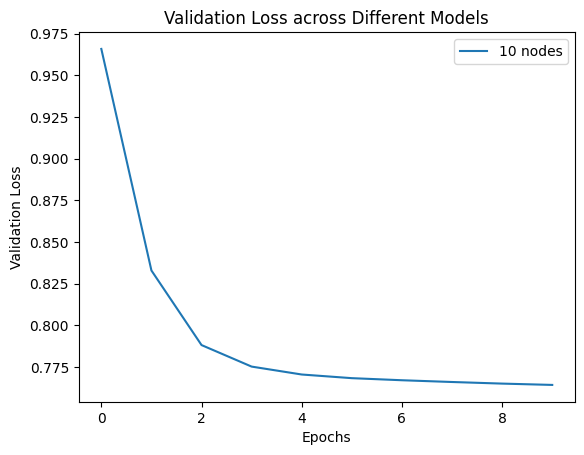

Epoch 1/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4400 - loss: 1.0548 - val_accuracy: 0.5474 - val_loss: 0.9802
Epoch 2/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5888 - loss: 0.9243 - val_accuracy: 0.6313 - val_loss: 0.8506
Epoch 3/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6590 - loss: 0.8097 - val_accuracy: 0.6623 - val_loss: 0.7958
Epoch 4/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6812 - loss: 0.7651 - val_accuracy: 0.6699 - val_loss: 0.7791
Epoch 5/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6869 - loss: 0.7493 - val_accuracy: 0.6705 - val_loss: 0.7732
Epoch 6/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6889 - loss: 0.7424 - val_accuracy: 0.6731 - val_loss: 0.7704
Epoch 7/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6904 - loss: 0.7384 - val_accuracy: 0.6727 - val_loss: 0.7685
Epoch 8/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6911 - loss: 0.7359 - 

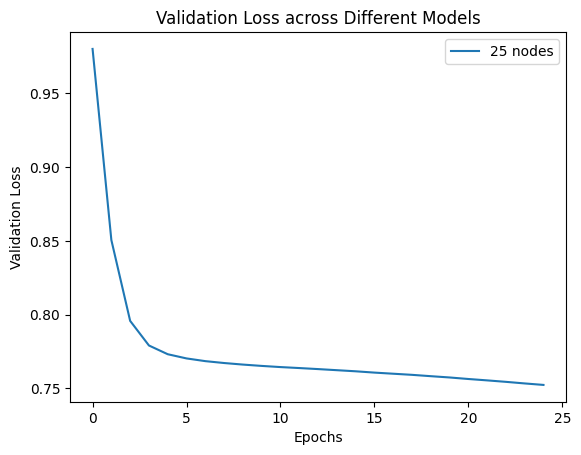

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4523 - loss: 1.0447 - val_accuracy: 0.5777 - val_loss: 0.9459
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6147 - loss: 0.8885 - val_accuracy: 0.6476 - val_loss: 0.8272
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6704 - loss: 0.7893 - val_accuracy: 0.6672 - val_loss: 0.7866
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6842 - loss: 0.7570 - val_accuracy: 0.6740 - val_loss: 0.7744
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6894 - loss: 0.7454 - val_accuracy: 0.6753 - val_loss: 0.7699
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6904 - loss: 0.7401 - val_accuracy: 0.6746 - val_loss: 0.7679
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6920 - loss: 0.7370 - val_accuracy: 0.6742 - val_loss: 0.7669
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6930 - loss: 0.7347 - 

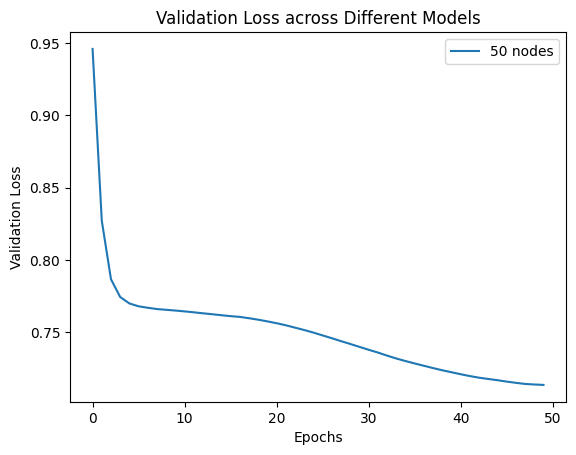

Epoch 1/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4440 - loss: 1.0532 - val_accuracy: 0.5736 - val_loss: 0.9528
Epoch 2/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6182 - loss: 0.8883 - val_accuracy: 0.6484 - val_loss: 0.8279
Epoch 3/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6711 - loss: 0.7871 - val_accuracy: 0.6670 - val_loss: 0.7881
Epoch 4/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6832 - loss: 0.7562 - val_accuracy: 0.6718 - val_loss: 0.7762
Epoch 5/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6874 - loss: 0.7452 - val_accuracy: 0.6747 - val_loss: 0.7716
Epoch 6/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6901 - loss: 0.7399 - val_accuracy: 0.6755 - val_loss: 0.7693
Epoch 7/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6923 - loss: 0.7367 - val_accuracy: 0.6747 - val_loss: 0.7678
Epoch 8/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6931 - loss: 0.7344 - 

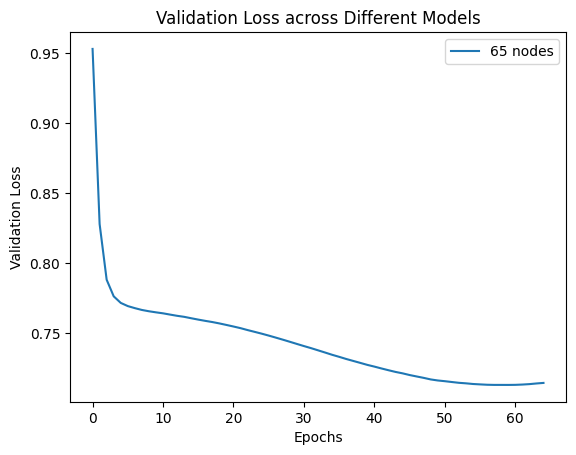

Epoch 1/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4321 - loss: 1.0554 - val_accuracy: 0.5461 - val_loss: 0.9749
Epoch 2/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5979 - loss: 0.9118 - val_accuracy: 0.6336 - val_loss: 0.8397
Epoch 3/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6643 - loss: 0.7968 - val_accuracy: 0.6631 - val_loss: 0.7906
Epoch 4/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6809 - loss: 0.7592 - val_accuracy: 0.6719 - val_loss: 0.7760
Epoch 5/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6878 - loss: 0.7461 - val_accuracy: 0.6755 - val_loss: 0.7708
Epoch 6/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6910 - loss: 0.7400 - val_accuracy: 0.6747 - val_loss: 0.7685
Epoch 7/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6914 - loss: 0.7364 - val_accuracy: 0.6740 - val_loss: 0.7670
Epoch 8/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6930 - loss: 0.7340 - 

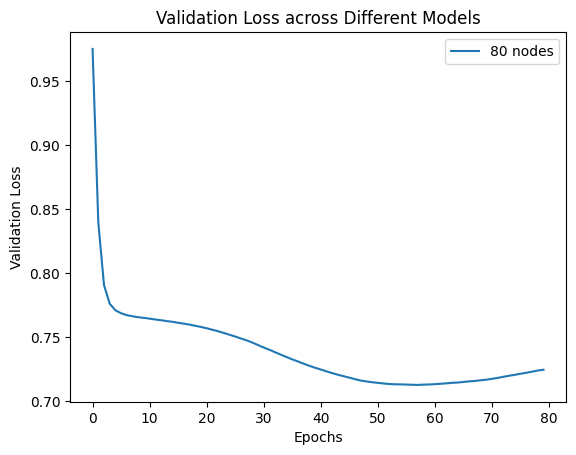

In [ ]:
num_epochs = [10, 25, 50, 65, 80]
for i in num_epochs:
    model_multi_node = build_model(32, 'relu', 'softmax')
    history = model_multi_node.fit(X_train, y_train, epochs=i, validation_data=(X_valid, y_valid))
    plt.plot(history.history['val_loss'], label=f'{i} nodes')
    plt.xlabel('Epochs')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss across Different Models')
    plt.legend()
    plt.show()


    


In [25]:
# With our testing, we concluded that the number of epochs needed had to be very high when using a lower number of nodes. We did not see any increase in the validation loss until 
# the number of nodes was increased to atleast 32 and 80 epochs which can be observed in the graphs above. This led us to use around 50 epochs when testing with the various number of nodes
# to look for overfitting. Using 1, 2, 4, 8, 16 nodes with less then 80 epochs did not show an increase after the initial decrease of the validation loss. Only using a higher number nodes, 
# 32 and 80 epochs did we see an increase. We decided to use 50 for the rest of the tests with the number of nodes.

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4110 - loss: 1.0750 - val_accuracy: 0.4199 - val_loss: 1.0771
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4120 - loss: 1.0626 - val_accuracy: 0.4199 - val_loss: 1.0661
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4373 - loss: 1.0450 - val_accuracy: 0.4921 - val_loss: 1.0236
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5258 - loss: 0.9914 - val_accuracy: 0.5411 - val_loss: 0.9610
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5639 - loss: 0.9315 - val_accuracy: 0.5609 - val_loss: 0.9242
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5785 - loss: 0.8999 - val_accuracy: 0.5707 - val_loss: 0.9084
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5885 - loss: 0.8860 - val_accuracy: 0.5777 - val_loss: 0.9016
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5948 - loss: 0.8793 - 

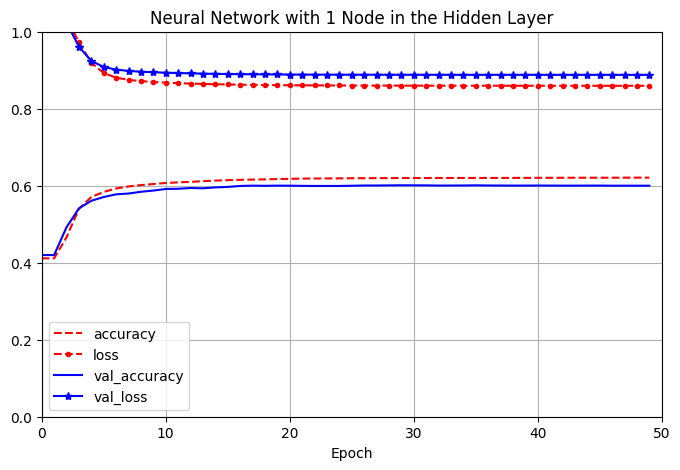

In [67]:
# Single Node in the Hidden Layer
model_single_node = build_model(1, 'relu', 'softmax')
single_node_history = model_single_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

pd.DataFrame(single_node_history.history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 1 Node in the Hidden Layer")
plt.show()

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4136 - loss: 1.0704 - val_accuracy: 0.5215 - val_loss: 1.0221
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5665 - loss: 0.9727 - val_accuracy: 0.5829 - val_loss: 0.9184
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6089 - loss: 0.8711 - val_accuracy: 0.6226 - val_loss: 0.8464
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6541 - loss: 0.8060 - val_accuracy: 0.6551 - val_loss: 0.8069
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6789 - loss: 0.7714 - val_accuracy: 0.6701 - val_loss: 0.7885
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6853 - loss: 0.7553 - val_accuracy: 0.6697 - val_loss: 0.7804
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6887 - loss: 0.7479 - val_accuracy: 0.6728 - val_loss: 0.7762
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6897 - loss: 0.7442 - 

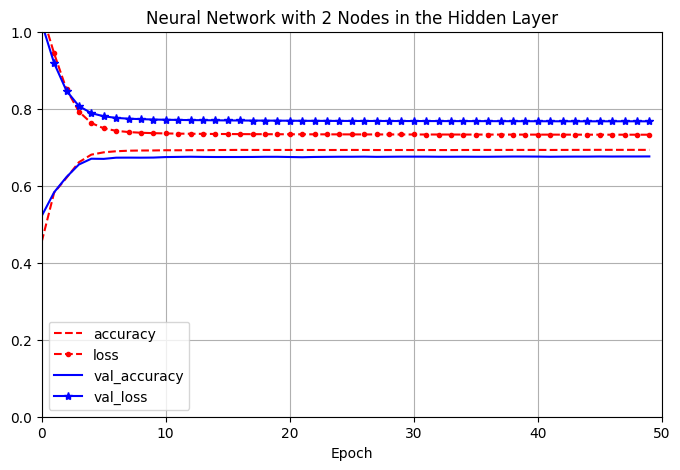

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4235 - loss: 1.0624 - val_accuracy: 0.5423 - val_loss: 0.9782
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5898 - loss: 0.9218 - val_accuracy: 0.6353 - val_loss: 0.8563
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6586 - loss: 0.8138 - val_accuracy: 0.6608 - val_loss: 0.8043
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6803 - loss: 0.7709 - val_accuracy: 0.6670 - val_loss: 0.7849
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6867 - loss: 0.7536 - val_accuracy: 0.6731 - val_loss: 0.7774
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6906 - loss: 0.7460 - val_accuracy: 0.6739 - val_loss: 0.7740
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6930 - loss: 0.7419 - val_accuracy: 0.6738 - val_loss: 0.7722
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6928 - loss: 0.7401 - 

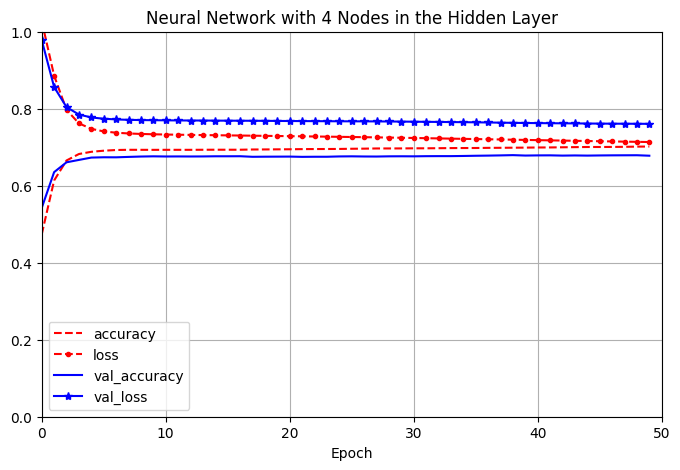

In [ ]:
model_two_node = build_model(2, 'relu', 'softmax')
two_node_history = model_two_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 2 Nodes in the Hidden Layer")
plt.show()

model_four_node = build_model(4, 'relu', 'softmax')
four_node_history = model_four_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 4 Nodes in the Hidden Layer")
plt.show()

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4194 - loss: 1.0484 - val_accuracy: 0.5725 - val_loss: 0.9536
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6193 - loss: 0.8944 - val_accuracy: 0.6547 - val_loss: 0.8243
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6730 - loss: 0.7872 - val_accuracy: 0.6697 - val_loss: 0.7848
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6845 - loss: 0.7563 - val_accuracy: 0.6743 - val_loss: 0.7738
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6884 - loss: 0.7460 - val_accuracy: 0.6762 - val_loss: 0.7700
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6908 - loss: 0.7414 - val_accuracy: 0.6757 - val_loss: 0.7684
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6924 - loss: 0.7387 - val_accuracy: 0.6736 - val_loss: 0.7675
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6921 - loss: 0.7373 - 

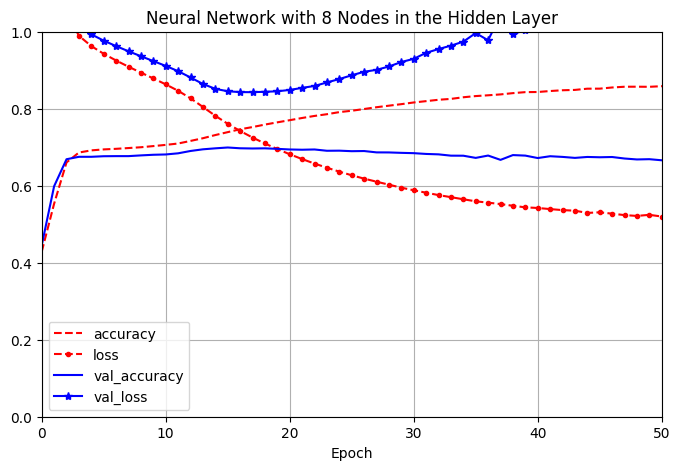

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4475 - loss: 1.0460 - val_accuracy: 0.5655 - val_loss: 0.9426
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6069 - loss: 0.8883 - val_accuracy: 0.6442 - val_loss: 0.8269
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6662 - loss: 0.7926 - val_accuracy: 0.6681 - val_loss: 0.7867
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6815 - loss: 0.7592 - val_accuracy: 0.6757 - val_loss: 0.7749
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6861 - loss: 0.7473 - val_accuracy: 0.6762 - val_loss: 0.7708
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6891 - loss: 0.7421 - val_accuracy: 0.6746 - val_loss: 0.7690
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6906 - loss: 0.7393 - val_accuracy: 0.6743 - val_loss: 0.7679
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6914 - loss: 0.7373 - 

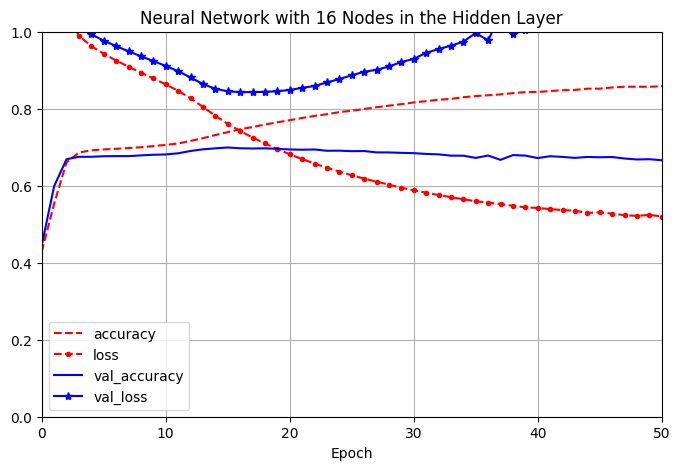

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4562 - loss: 1.0466 - val_accuracy: 0.5864 - val_loss: 0.9457
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6232 - loss: 0.8852 - val_accuracy: 0.6568 - val_loss: 0.8197
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6738 - loss: 0.7834 - val_accuracy: 0.6689 - val_loss: 0.7834
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6863 - loss: 0.7543 - val_accuracy: 0.6703 - val_loss: 0.7739
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6902 - loss: 0.7447 - val_accuracy: 0.6713 - val_loss: 0.7708
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6914 - loss: 0.7404 - val_accuracy: 0.6731 - val_loss: 0.7695
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6919 - loss: 0.7378 - val_accuracy: 0.6736 - val_loss: 0.7688
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6928 - loss: 0.7360 - 

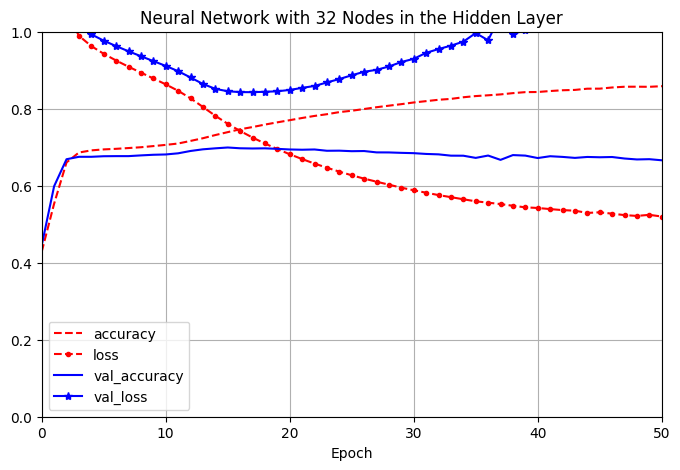

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4353 - loss: 1.0535 - val_accuracy: 0.5589 - val_loss: 0.9673
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6076 - loss: 0.9095 - val_accuracy: 0.6437 - val_loss: 0.8315
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6688 - loss: 0.7936 - val_accuracy: 0.6662 - val_loss: 0.7860
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6832 - loss: 0.7570 - val_accuracy: 0.6720 - val_loss: 0.7733
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6895 - loss: 0.7443 - val_accuracy: 0.6732 - val_loss: 0.7687
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6922 - loss: 0.7385 - val_accuracy: 0.6740 - val_loss: 0.7666
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6930 - loss: 0.7350 - val_accuracy: 0.6742 - val_loss: 0.7654
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6941 - loss: 0.7326 - 

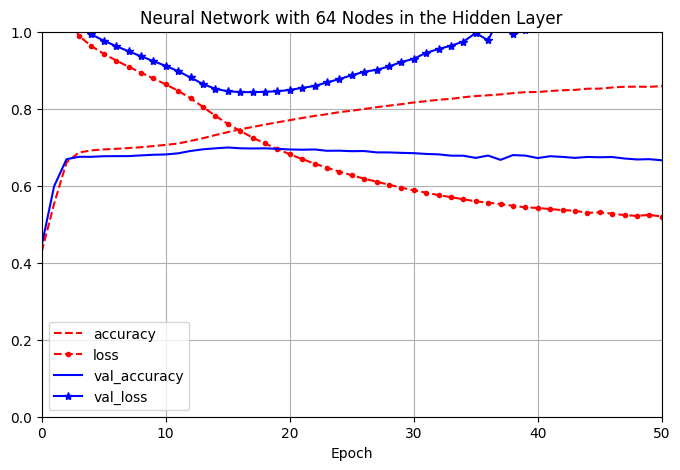

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4537 - loss: 1.0494 - val_accuracy: 0.5739 - val_loss: 0.9556
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6168 - loss: 0.8963 - val_accuracy: 0.6448 - val_loss: 0.8267
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6686 - loss: 0.7884 - val_accuracy: 0.6615 - val_loss: 0.7855
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6846 - loss: 0.7550 - val_accuracy: 0.6693 - val_loss: 0.7742
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6885 - loss: 0.7434 - val_accuracy: 0.6709 - val_loss: 0.7703
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6918 - loss: 0.7378 - val_accuracy: 0.6718 - val_loss: 0.7684
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6927 - loss: 0.7344 - val_accuracy: 0.6746 - val_loss: 0.7674
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6941 - loss: 0.7318 - 

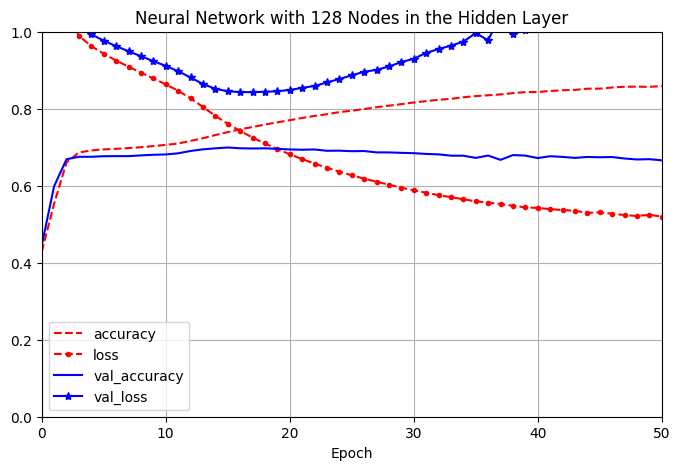

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4718 - loss: 1.0459 - val_accuracy: 0.5744 - val_loss: 0.9524
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6156 - loss: 0.8922 - val_accuracy: 0.6506 - val_loss: 0.8267
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6714 - loss: 0.7862 - val_accuracy: 0.6665 - val_loss: 0.7836
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6861 - loss: 0.7524 - val_accuracy: 0.6732 - val_loss: 0.7720
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6908 - loss: 0.7410 - val_accuracy: 0.6750 - val_loss: 0.7681
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6917 - loss: 0.7355 - val_accuracy: 0.6759 - val_loss: 0.7664
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6933 - loss: 0.7319 - val_accuracy: 0.6770 - val_loss: 0.7653
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6950 - loss: 0.7291 - 

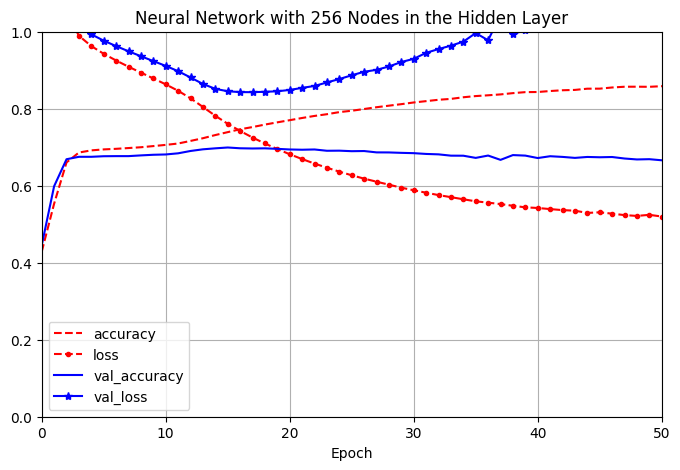

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4761 - loss: 1.0416 - val_accuracy: 0.5941 - val_loss: 0.9388
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6309 - loss: 0.8801 - val_accuracy: 0.6531 - val_loss: 0.8182
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6764 - loss: 0.7799 - val_accuracy: 0.6680 - val_loss: 0.7802
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6865 - loss: 0.7493 - val_accuracy: 0.6743 - val_loss: 0.7700
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6906 - loss: 0.7385 - val_accuracy: 0.6781 - val_loss: 0.7664
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6928 - loss: 0.7331 - val_accuracy: 0.6774 - val_loss: 0.7648
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6945 - loss: 0.7294 - val_accuracy: 0.6774 - val_loss: 0.7637
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6956 - loss: 0.7263 - 

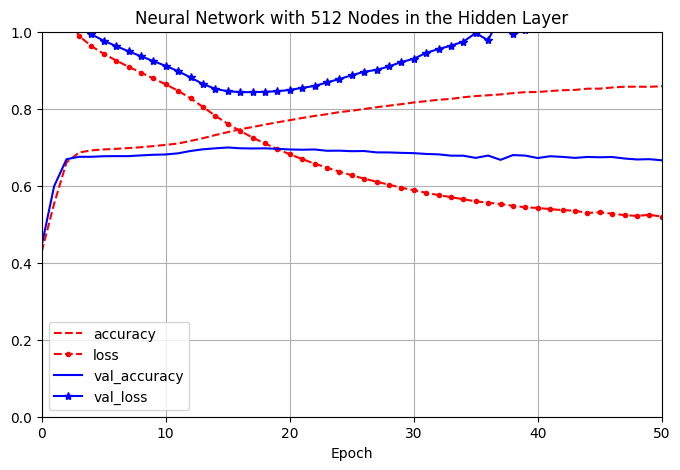

In [75]:
num_nodes = [8, 16, 32, 64, 128, 256, 512]
multi_history = []
for index, i in enumerate(num_nodes):
    model_multi_node = build_model(i, 'relu', 'softmax')
    multi_history.append(model_multi_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))) 

    pd.DataFrame(multi_history[index].history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
    plt.legend(loc="lower left") 
    plt.title(f"Neural Network with {i} Nodes in the Hidden Layer")
    plt.show()


In [29]:
# When using 8 and 16 nodes in the hidden layer,
# we can observe that the validation loss decreases and then flattens out and becomes stable
# this implies that there is underfitting

# When using 32 and 64 nodes in the hidden layer,
# we can observe that the validation loss as well as the training loss decrease
# to lower than when we tried 8 and 16 nodes
# The accuracy in this case also improves much more
# it seems that around the 32 and 64 range is the optimal number of nodes for our use case

# When using 128, 256, and 512 nodes in the hidden layer,
# we can observe that the validation loss slightly increases and the training loss decreases
# this can be a sign of overfitting since the model is overfitting to the training set
# and performing worse on the validation set

    - **Varying the number of layers**.

        - Conduct similar experiments as described above, but this time vary the number of layers from 1 to 4. Document your findings.

        - How many nodes should each layer contain? Test at least two scenarios. Traditionally, a common strategy involved decreasing the number of nodes from the input layer to the output layer, often by halving, to create a pyramid-like structure. However, recent experience suggests that maintaining a constant number of nodes across all layers can perform equally well. Describe your observations. It is acceptable if both strategies yield similar performance results.

        - Select one your models that exemplifies overfitting. In our experiments, we easily constructed a model achieving nearly 100% accuracy on the training data, yet showing no similar improvement on the validation set. Present this neural network along with its accuracy and loss graphs. Explain the reasoning for concluding that the model is overfitting.

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4494 - loss: 1.0567 - val_accuracy: 0.5605 - val_loss: 0.9658
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5996 - loss: 0.8962 - val_accuracy: 0.6448 - val_loss: 0.8205
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6705 - loss: 0.7792 - val_accuracy: 0.6700 - val_loss: 0.7805
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6857 - loss: 0.7480 - val_accuracy: 0.6727 - val_loss: 0.7708
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6886 - loss: 0.7379 - val_accuracy: 0.6773 - val_loss: 0.7663
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6910 - loss: 0.7327 - val_accuracy: 0.6782 - val_loss: 0.7634
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6934 - loss: 0.7291 - val_accuracy: 0.6788 - val_loss: 0.7619
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6950 - loss: 0.7260 - 

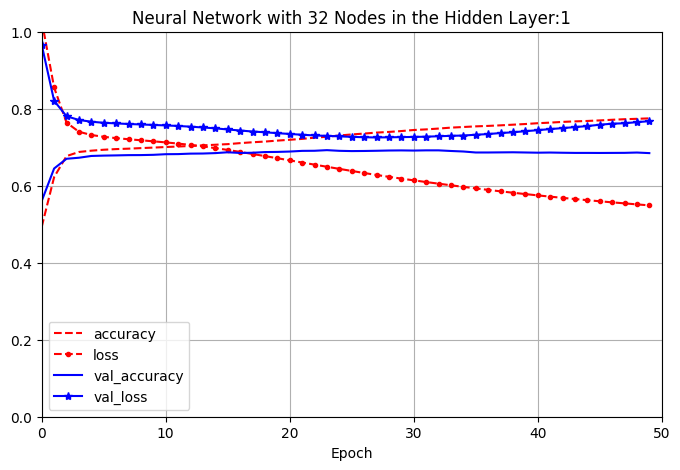

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4024 - loss: 1.0720 - val_accuracy: 0.4489 - val_loss: 1.0595
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4982 - loss: 1.0199 - val_accuracy: 0.5605 - val_loss: 0.9178
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5981 - loss: 0.8696 - val_accuracy: 0.6407 - val_loss: 0.8124
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6702 - loss: 0.7748 - val_accuracy: 0.6688 - val_loss: 0.7767
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6874 - loss: 0.7455 - val_accuracy: 0.6728 - val_loss: 0.7687
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6911 - loss: 0.7369 - val_accuracy: 0.6755 - val_loss: 0.7655
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6926 - loss: 0.7329 - val_accuracy: 0.6769 - val_loss: 0.7639
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6939 - loss: 0.7303 - 

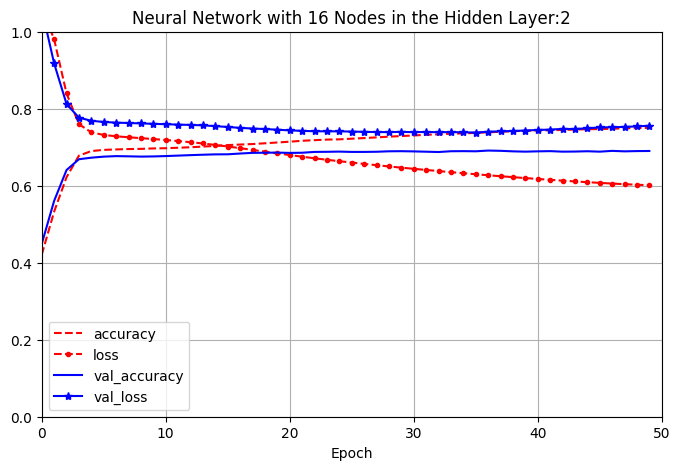

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4032 - loss: 1.0688 - val_accuracy: 0.4192 - val_loss: 1.0727
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4200 - loss: 1.0547 - val_accuracy: 0.4747 - val_loss: 1.0185
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5123 - loss: 0.9682 - val_accuracy: 0.5484 - val_loss: 0.9208
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5725 - loss: 0.8864 - val_accuracy: 0.6001 - val_loss: 0.8697
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6365 - loss: 0.8196 - val_accuracy: 0.6601 - val_loss: 0.7967
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6825 - loss: 0.7571 - val_accuracy: 0.6700 - val_loss: 0.7785
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6895 - loss: 0.7433 - val_accuracy: 0.6731 - val_loss: 0.7735
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6909 - loss: 0.7387 - 

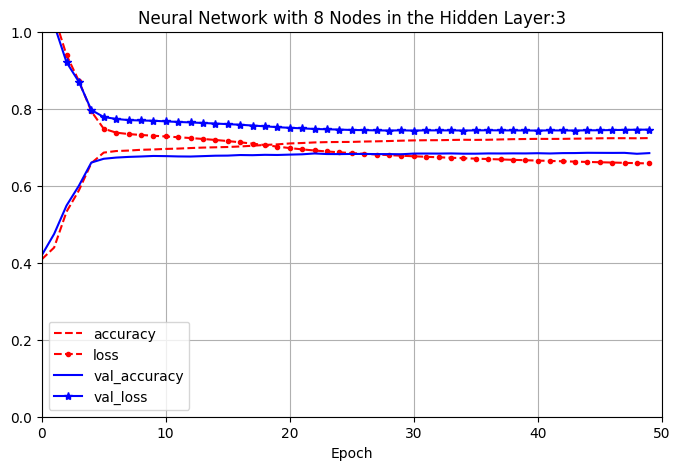

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4145 - loss: 1.0700 - val_accuracy: 0.4476 - val_loss: 1.0617
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5095 - loss: 1.0219 - val_accuracy: 0.5827 - val_loss: 0.9388
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6052 - loss: 0.9062 - val_accuracy: 0.6022 - val_loss: 0.8988
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6173 - loss: 0.8742 - val_accuracy: 0.6039 - val_loss: 0.8894
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6200 - loss: 0.8655 - val_accuracy: 0.6041 - val_loss: 0.8857
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6205 - loss: 0.8611 - val_accuracy: 0.6022 - val_loss: 0.8827
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6200 - loss: 0.8572 - val_accuracy: 0.6018 - val_loss: 0.8797
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6203 - loss: 0.8527 - 

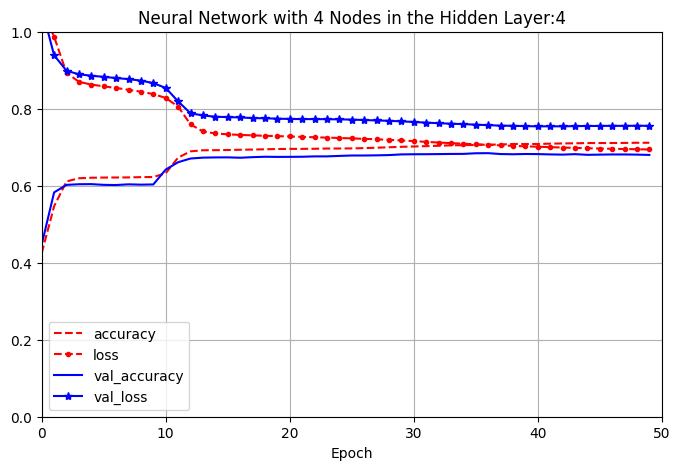

In [ ]:
# Code cell
# Strategy 1, 4 layers with nodes that are halved each at each layer
num_layers = [1,2,3,4]
num_nodes = 32
changing_history = []
for i in num_layers:
    model_multi_node = build_model(num_nodes, 'relu', 'softmax', i)
    changing_history.append(model_multi_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid)))
  
    pd.DataFrame(changing_history[i-1].history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
    plt.legend(loc="lower left") 
    plt.title(f"Neural Network with {num_nodes} Nodes in the Hidden Layer:{i}")
    plt.show()
    num_nodes = num_nodes // 2

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4218 - loss: 1.0690 - val_accuracy: 0.4974 - val_loss: 1.0312
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5489 - loss: 0.9748 - val_accuracy: 0.6268 - val_loss: 0.8484
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6585 - loss: 0.8023 - val_accuracy: 0.6681 - val_loss: 0.7833
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6838 - loss: 0.7545 - val_accuracy: 0.6730 - val_loss: 0.7731
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6899 - loss: 0.7429 - val_accuracy: 0.6720 - val_loss: 0.7700
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6909 - loss: 0.7375 - val_accuracy: 0.6743 - val_loss: 0.7684
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6924 - loss: 0.7336 - val_accuracy: 0.6761 - val_loss: 0.7668
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6934 - loss: 0.7302 - 

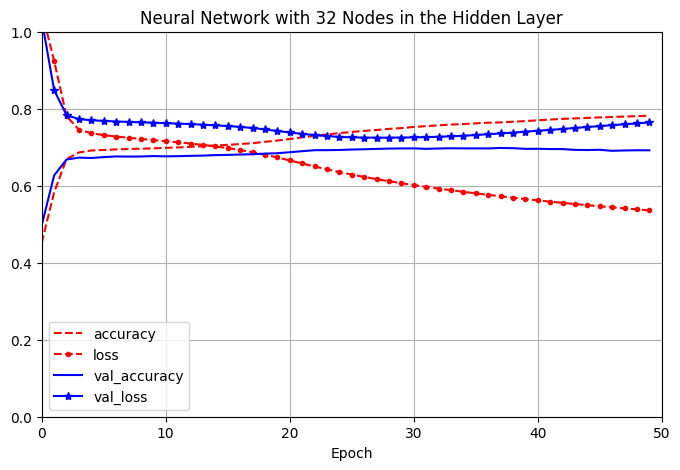

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4073 - loss: 1.0667 - val_accuracy: 0.4755 - val_loss: 1.0345
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5320 - loss: 0.9715 - val_accuracy: 0.6341 - val_loss: 0.8346
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6613 - loss: 0.7886 - val_accuracy: 0.6659 - val_loss: 0.7777
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6861 - loss: 0.7455 - val_accuracy: 0.6738 - val_loss: 0.7676
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6909 - loss: 0.7348 - val_accuracy: 0.6778 - val_loss: 0.7639
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6918 - loss: 0.7297 - val_accuracy: 0.6801 - val_loss: 0.7620
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6940 - loss: 0.7259 - val_accuracy: 0.6820 - val_loss: 0.7603
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6953 - loss: 0.7226 - 

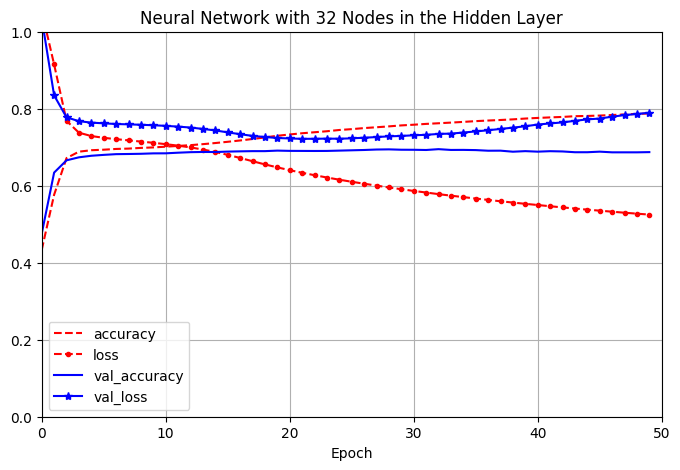

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4307 - loss: 1.0662 - val_accuracy: 0.5198 - val_loss: 1.0199
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5721 - loss: 0.9460 - val_accuracy: 0.6290 - val_loss: 0.8446
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6595 - loss: 0.7961 - val_accuracy: 0.6705 - val_loss: 0.7778
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6866 - loss: 0.7473 - val_accuracy: 0.6740 - val_loss: 0.7685
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6913 - loss: 0.7359 - val_accuracy: 0.6740 - val_loss: 0.7651
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6932 - loss: 0.7303 - val_accuracy: 0.6736 - val_loss: 0.7634
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6948 - loss: 0.7262 - val_accuracy: 0.6746 - val_loss: 0.7622
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6966 - loss: 0.7225 - 

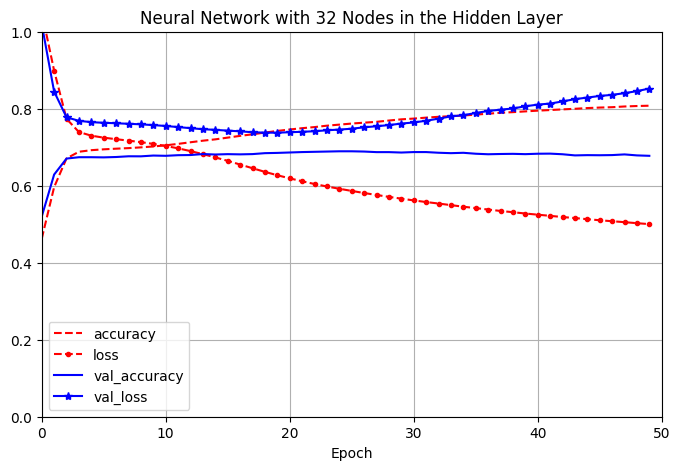

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4147 - loss: 1.0672 - val_accuracy: 0.4416 - val_loss: 1.0580
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5113 - loss: 1.0082 - val_accuracy: 0.6367 - val_loss: 0.8398
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6617 - loss: 0.7902 - val_accuracy: 0.6691 - val_loss: 0.7844
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6867 - loss: 0.7435 - val_accuracy: 0.6716 - val_loss: 0.7714
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6904 - loss: 0.7333 - val_accuracy: 0.6743 - val_loss: 0.7676
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6944 - loss: 0.7280 - val_accuracy: 0.6749 - val_loss: 0.7654
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6964 - loss: 0.7241 - val_accuracy: 0.6774 - val_loss: 0.7638
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6981 - loss: 0.7206 - 

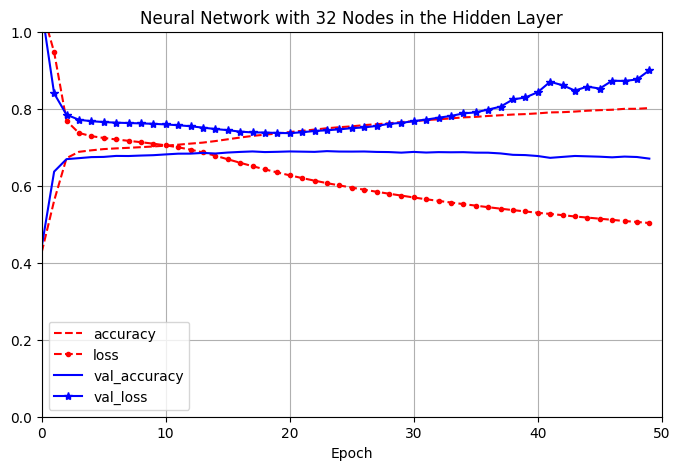

In [ ]:
# Strategy 2, Constant number of nodes
num_layers = [1,2,3,4]
num_nodes = 32
constant_history = []
for i in num_layers:
    model_multi_node = build_model(num_nodes, 'relu', 'softmax', i)
    constant_history.append(model_multi_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))) 
    pd.DataFrame(constant_history[i-1].history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
    plt.legend(loc="lower left") 
    plt.title(f"Neural Network with {num_nodes} Nodes in the Hidden Layer")
    plt.show()
    

In [ ]:
# As we can see in the graphs above, regardless of which experiment it seems that when the node count is higher, we can observe overfitting occuring. 
# the experiment in which the layers would change and the nodes would halve each time, we can see when it was at 32 nodes and the it was at 1 hidden layer there 
# was an incrfease in the validation loss near the end which shows overfitting. As the nodes decreased it became harder to observe that. In the constant node 
# experiment it was apparent in all the graphs. 

    - **Activation function**.

        - Present results for one of the configurations mentioned above by varying the activation function. Test at least `relu` (the default) and `sigmoid`. The choice of the specific model, including the number of layers and nodes, is at your discretion. Document your observations accordingly.

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4390 - loss: 1.0570 - val_accuracy: 0.5655 - val_loss: 0.9620
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6080 - loss: 0.9030 - val_accuracy: 0.6487 - val_loss: 0.8287
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6680 - loss: 0.7916 - val_accuracy: 0.6647 - val_loss: 0.7844
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6843 - loss: 0.7560 - val_accuracy: 0.6709 - val_loss: 0.7727
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6895 - loss: 0.7441 - val_accuracy: 0.6730 - val_loss: 0.7691
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6911 - loss: 0.7386 - val_accuracy: 0.6713 - val_loss: 0.7677
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6921 - loss: 0.7355 - val_accuracy: 0.6719 - val_loss: 0.7668
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6931 - loss: 0.7330 - 

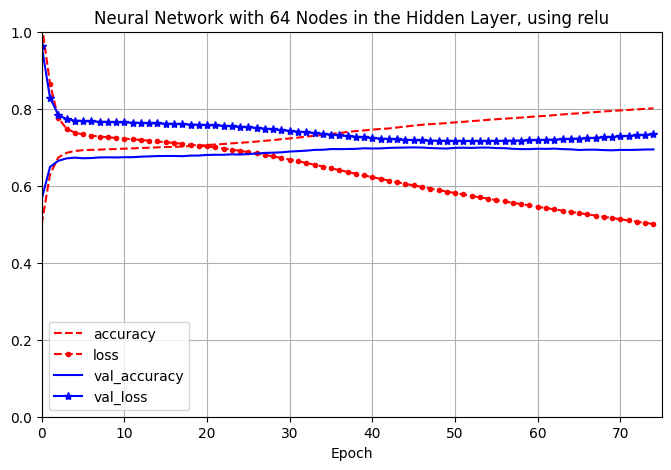

In [ ]:
# Code cell
model_relu = build_model(64, 'relu', 'softmax')
history_relu = model_relu.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))

pd.DataFrame(history_relu.history).plot(
    figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 Nodes in the Hidden Layer, using relu")
plt.show()

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4345 - loss: 1.0634 - val_accuracy: 0.4312 - val_loss: 1.0582
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5059 - loss: 1.0381 - val_accuracy: 0.4825 - val_loss: 1.0336
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5618 - loss: 1.0092 - val_accuracy: 0.5522 - val_loss: 1.0021
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5907 - loss: 0.9729 - val_accuracy: 0.5815 - val_loss: 0.9649
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6012 - loss: 0.9325 - val_accuracy: 0.5916 - val_loss: 0.9268
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6136 - loss: 0.8932 - val_accuracy: 0.6067 - val_loss: 0.8918
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6300 - loss: 0.8588 - val_accuracy: 0.6224 - val_loss: 0.8619
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6485 - loss: 0.8299 - 

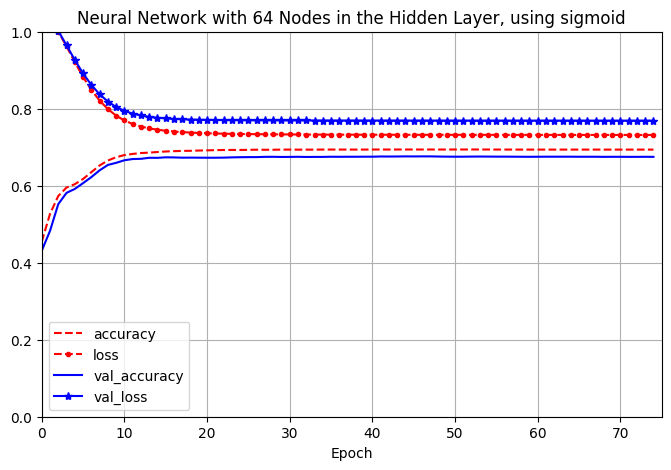

In [ ]:
model_sigmoid = build_model(64, 'sigmoid', 'softmax')
history_sigmoid = model_sigmoid.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))

pd.DataFrame(history_sigmoid.history).plot(
    figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 Nodes in the Hidden Layer, using sigmoid")
plt.show()

    - **Regularization** in neural networks is a technique used to prevent overfitting.

        - One technique involves adding a penalty to the loss function to discourage excessively complex models. Apply an `l2` penalty to some or all layers. Exercise caution, as overly aggressive penalties have been problematic in our experiments. Begin with the default `l2` value of 0.01, then reduce it to 0.001 and 1e-4. Select a specific model from the above experiments and present a case where you successfully reduced overfitting. Include a pair of graphs comparing results with and without regularization. Explain your rationale to conclude that overfitting has been reduced. Do not expect to completely eliminate overfitting. Again, this is a challenging dataset to work with.

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4259 - loss: 1.0666 - val_accuracy: 0.4872 - val_loss: 1.0432
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5507 - loss: 0.9686 - val_accuracy: 0.6469 - val_loss: 0.8207
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6662 - loss: 0.7763 - val_accuracy: 0.6692 - val_loss: 0.7786
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6851 - loss: 0.7433 - val_accuracy: 0.6720 - val_loss: 0.7697
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6899 - loss: 0.7330 - val_accuracy: 0.6747 - val_loss: 0.7651
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6934 - loss: 0.7268 - val_accuracy: 0.6757 - val_loss: 0.7633
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6964 - loss: 0.7219 - val_accuracy: 0.6757 - val_loss: 0.7625
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6983 - loss: 0.7172 - 

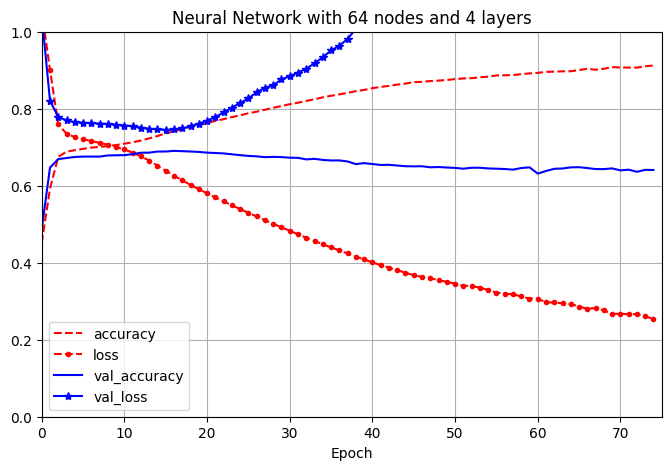

In [66]:
model = build_model(64, 'relu', 'softmax', 4)
history_no_l2 = model.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))

pd.DataFrame(history_no_l2.history).plot(figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch", style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 nodes and 4 layers")
plt.show()


In [72]:
def build_model_l2(num_nodes, activation_hidden, activation_output, layers=1, use_l2=None):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=[462]))
    for _ in range(layers):
        model.add(tf.keras.layers.Dense(num_nodes, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(use_l2)))    
    model.add(tf.keras.layers.Dense(3, activation=activation_output))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4091 - loss: 3.6115 - val_accuracy: 0.4199 - val_loss: 2.5286
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4200 - loss: 2.2896 - val_accuracy: 0.4214 - val_loss: 1.7759
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4858 - loss: 1.6496 - val_accuracy: 0.5882 - val_loss: 1.3642
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6078 - loss: 1.2611 - val_accuracy: 0.6052 - val_loss: 1.1242
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6172 - loss: 1.0767 - val_accuracy: 0.6035 - val_loss: 1.0376
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6175 - loss: 1.0023 - val_accuracy: 0.6032 - val_loss: 0.9946
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6171 - loss: 0.9651 - val_accuracy: 0.6041 - val_loss: 0.9721
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6170 - loss: 0.9452 - 

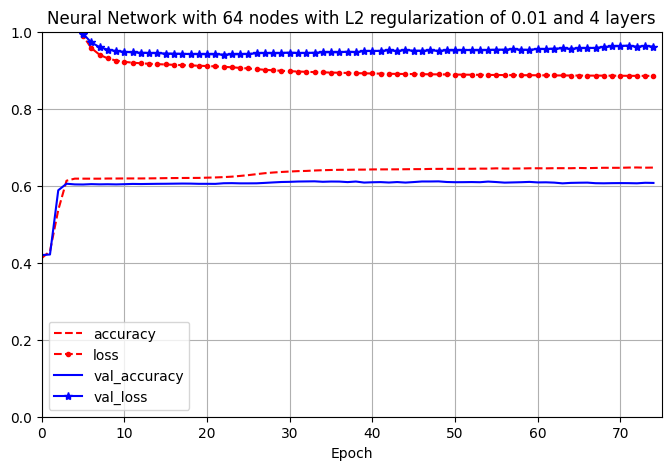

In [ ]:
# Code cell


l2_model = build_model_l2(64 , 'relu', 'softmax', 4, 0.01)
history_l2 = l2_model.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))

pd.DataFrame(history_l2.history).plot(figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch", style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 nodes with L2 regularization of 0.01 and 4 layers")
plt.show()

In [ ]:
# using l2 with a value of 0.01 we can see that the regularization has indeed caused a reduction in overfitting.
# Comparing the two graphs we can see that around epoch 20 the validation loss starts to drastically increase.
# When using l2 regularization on all the layers with a value of 0.01 we can observe that even at around 20 epoch there are is no drastic 
# increase in validation loss.This indicates there was a reduction in overfitting. 

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4143 - loss: 1.3682 - val_accuracy: 0.5057 - val_loss: 1.3182
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5690 - loss: 1.2307 - val_accuracy: 0.6516 - val_loss: 1.0791
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6756 - loss: 1.0345 - val_accuracy: 0.6707 - val_loss: 1.0328
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6873 - loss: 0.9919 - val_accuracy: 0.6704 - val_loss: 1.0100
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6904 - loss: 0.9683 - val_accuracy: 0.6735 - val_loss: 0.9920
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6928 - loss: 0.9487 - val_accuracy: 0.6744 - val_loss: 0.9757
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6937 - loss: 0.9312 - val_accuracy: 0.6759 - val_loss: 0.9613
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6954 - loss: 0.9150 - 

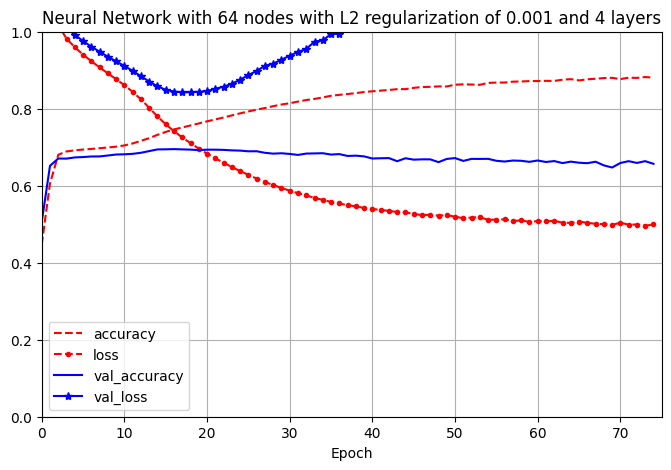

In [74]:
l2_model_2 = build_model_l2(64 , 'relu', 'softmax', 4, 0.001)
history_l2_2 = l2_model_2.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))

pd.DataFrame(history_l2_2.history).plot(figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch", style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 nodes with L2 regularization of 0.001 and 4 layers")
plt.show()

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4155 - loss: 1.0994 - val_accuracy: 0.5187 - val_loss: 1.0558
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5683 - loss: 0.9790 - val_accuracy: 0.6385 - val_loss: 0.8629
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6642 - loss: 0.8149 - val_accuracy: 0.6662 - val_loss: 0.8088
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6860 - loss: 0.7742 - val_accuracy: 0.6697 - val_loss: 0.7987
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6924 - loss: 0.7624 - val_accuracy: 0.6735 - val_loss: 0.7949
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6961 - loss: 0.7559 - val_accuracy: 0.6747 - val_loss: 0.7929
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6984 - loss: 0.7506 - val_accuracy: 0.6763 - val_loss: 0.7914
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7007 - loss: 0.7456 - 

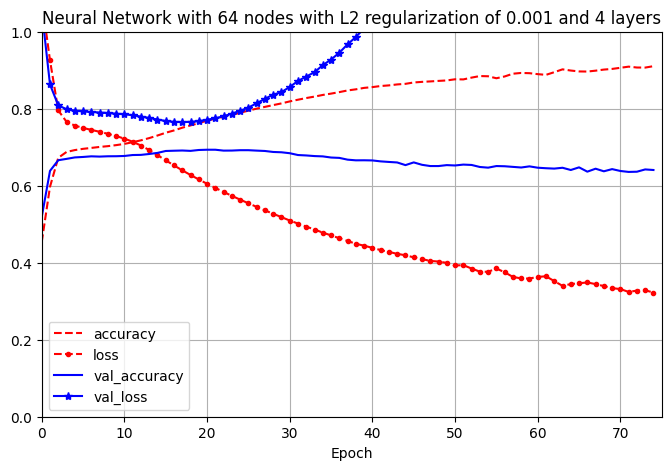

In [70]:
l2_model_3 = build_model_l2(64 , 'relu', 'softmax', 4, 0.0001)
history_l2_3 = l2_model_3.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))

pd.DataFrame(history_l2_3.history).plot(figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch", style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 nodes with L2 regularization of 0.0001 and 4 layers")
plt.show()

        - Dropout layers are a regularization technique in neural networks where a random subset of neurons is temporarily removed during training. This helps prevent overfitting by promoting redundancy and improving the network's ability to generalize to new data. Select a specific model from the above experiments where you have muliple layers and experiment adding one or of few dropout layers into your network. Experiment with two different rates, say 0.25 and 0.5. Document your observations.

In [76]:
# Code cell
def build_model_dropout(num_nodes, dropout_rate, layers, num_dropout_layers):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=[462]))

    for _ in range(layers):
        model.add(tf.keras.layers.Dense(num_nodes))
        if num_dropout_layers >= 1:
            model.add(tf.keras.layers.Dropout(dropout_rate))
            num_dropout_layers -= 1
    model.add(tf.keras.layers.Dense(3, activation='softmax')) 
    model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5187 - loss: 0.9783 - val_accuracy: 0.6622 - val_loss: 0.8020
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6557 - loss: 0.8027 - val_accuracy: 0.6727 - val_loss: 0.7806
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6692 - loss: 0.7810 - val_accuracy: 0.6720 - val_loss: 0.7757
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6801 - loss: 0.7679 - val_accuracy: 0.6744 - val_loss: 0.7745
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6811 - loss: 0.7671 - val_accuracy: 0.6750 - val_loss: 0.7732
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6796 - loss: 0.7636 - val_accuracy: 0.6759 - val_loss: 0.7729
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6812 - loss: 0.7619 - val_accuracy: 0.6753 - val_loss: 0.7719
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6823 - loss: 0.7591 - 

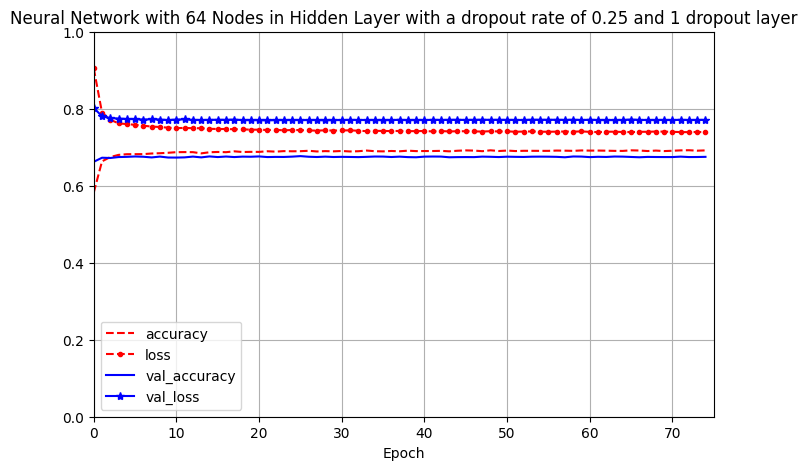

In [77]:
model_dropout = build_model_dropout(64, 0.25, 8, 1)
history_dropout = model_dropout.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))
pd.DataFrame(history_dropout.history).plot(
    figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 Nodes in Hidden Layer with a dropout rate of 0.25 and 1 dropout layer")
plt.show()

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4535 - loss: 1.0419 - val_accuracy: 0.6283 - val_loss: 0.8430
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6210 - loss: 0.8619 - val_accuracy: 0.6622 - val_loss: 0.7878
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6597 - loss: 0.8065 - val_accuracy: 0.6709 - val_loss: 0.7808
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6661 - loss: 0.7941 - val_accuracy: 0.6704 - val_loss: 0.7771
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6691 - loss: 0.7863 - val_accuracy: 0.6740 - val_loss: 0.7734
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6734 - loss: 0.7788 - val_accuracy: 0.6740 - val_loss: 0.7733
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6757 - loss: 0.7783 - val_accuracy: 0.6746 - val_loss: 0.7703
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6765 - loss: 0.7761 - 

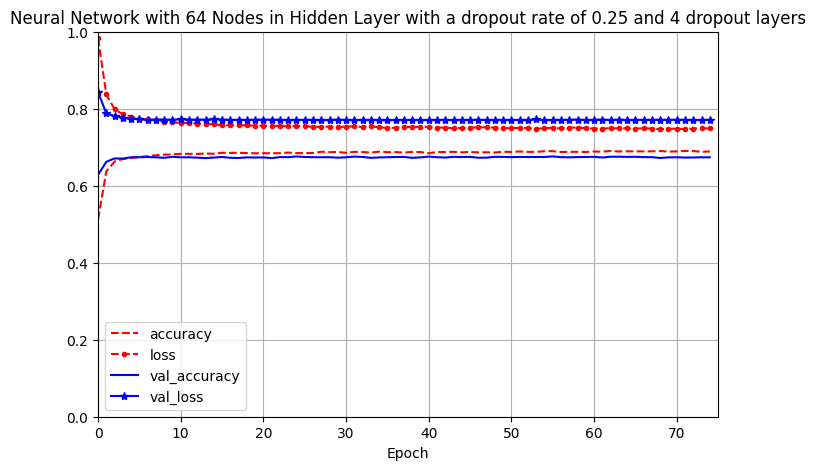

In [78]:
model_dropout = build_model_dropout(64, 0.25, 8, 4)
history_dropout = model_dropout.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))
pd.DataFrame(history_dropout.history).plot(
    figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 Nodes in Hidden Layer with a dropout rate of 0.25 and 4 dropout layers")
plt.show()

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4769 - loss: 1.0242 - val_accuracy: 0.6222 - val_loss: 0.8593
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6212 - loss: 0.8588 - val_accuracy: 0.6577 - val_loss: 0.7993
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6516 - loss: 0.8127 - val_accuracy: 0.6681 - val_loss: 0.7834
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6636 - loss: 0.7948 - val_accuracy: 0.6720 - val_loss: 0.7777
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6680 - loss: 0.7857 - val_accuracy: 0.6713 - val_loss: 0.7777
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6713 - loss: 0.7806 - val_accuracy: 0.6738 - val_loss: 0.7746
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6735 - loss: 0.7769 - val_accuracy: 0.6731 - val_loss: 0.7756
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6775 - loss: 0.7720 - 

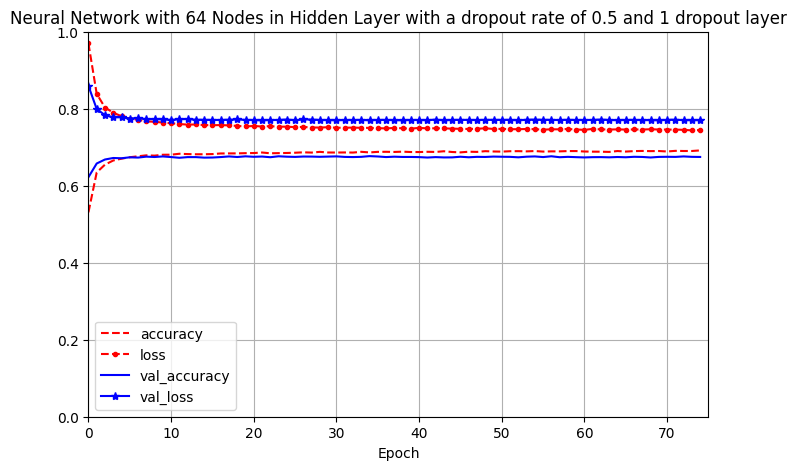

In [79]:
model_dropout = build_model_dropout(64, 0.5, 8, 1)
history_dropout = model_dropout.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))
pd.DataFrame(history_dropout.history).plot(
    figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 Nodes in Hidden Layer with a dropout rate of 0.5 and 1 dropout layer")
plt.show()

Epoch 1/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4003 - loss: 1.0894 - val_accuracy: 0.4414 - val_loss: 1.0499
Epoch 2/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4647 - loss: 1.0310 - val_accuracy: 0.5932 - val_loss: 0.9109
Epoch 3/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5633 - loss: 0.9399 - val_accuracy: 0.6417 - val_loss: 0.8336
Epoch 4/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6156 - loss: 0.8766 - val_accuracy: 0.6605 - val_loss: 0.8043
Epoch 5/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6388 - loss: 0.8490 - val_accuracy: 0.6659 - val_loss: 0.7904
Epoch 6/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6446 - loss: 0.8339 - val_accuracy: 0.6682 - val_loss: 0.7850
Epoch 7/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6505 - loss: 0.8221 - val_accuracy: 0.6708 - val_loss: 0.7845
Epoch 8/75
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6551 - loss: 0.8182 - 

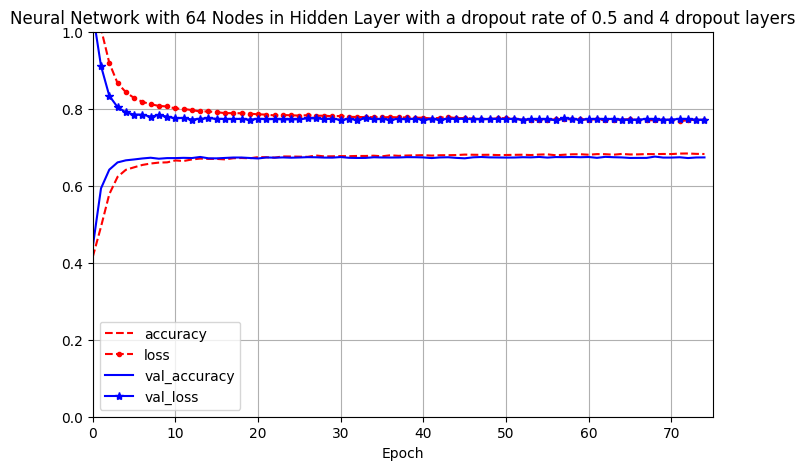

In [80]:
model_dropout = build_model_dropout(64, 0.5, 8, 4)
history_dropout = model_dropout.fit(X_train, y_train, epochs=75, validation_data=(X_valid, y_valid))
pd.DataFrame(history_dropout.history).plot(
    figsize=(8, 5), xlim=[0, 75], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 64 Nodes in Hidden Layer with a dropout rate of 0.5 and 4 dropout layers")
plt.show()

In [ ]:
# We can observe that when we use a higher dropout rate (0.5), the accurate decreases and reduces overfitting
# when the dropout rate is lower (0.25), the accuracy does not decrease as much, but is still overfitting more than (0.5 dropout rate)

# when the number of dropout layers is lower like when we used 1, the model started to overfit less and the accuracy decreased slightly
# when the number as the number of dropout layers increases, the model starts to underfit more since there are more neurons being temporarily removed

# ultimately, this displays the tradeoff of accuracy and overfitting, and how we need to choose the best parameters for the best performance

        - Summarize your experiments with using a graphical representation such as Figure 6.15 [on this page](https://egallic.fr/Enseignement/ML/ECB/book/deep-learning.html).

In [ ]:
# Code cell

experiments = {
    "1 Node History": single_node_history,  
    "2 Node History": two_node_history,
    "4 Node History": four_node_history,
    "8 Node History": multi_history[0],
    "16 Node History": multi_history[1],
    "32 Node History" : multi_history[2],
    "64 Node History": multi_history[4],
    "128 Node History": multi_history[5],
    "256 Node History": multi_history[6],
    "512 Node History": multi_history[7],
    "4 Layer 32 Node History": changing_history[0],
    "3 Layer 16 Node History": changing_history[1],
    "2 Layer 8 Node History": changing_history[2],
    "1 Layer 4 Node History": changing_history[3],
    "4 Layer 32 Constant Node History": changing_history[0],
    "3 Layer 32 Constant Node History": changing_history[1],
    "2 Layer 32 Constant Node History": changing_history[2],
    "1 Layer 32 Constant Node History": changing_history[3],
    "Sigmoid History": history_sigmoid,
    "Relu History": history_relu,
    "No L2 Regularization": history_no_l2,
    "L2 Regularization 0.01": history_l2,
    "L2 Regularization 0.001": history_l2_2,
    "L2 Regularization 0.0001": history_l2_3
     
    
}

metrics = ['accuracy', 'loss']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    for label, history in experiments.items():
        plt.plot(history.history[metric], label=f"{label} - Train {metric}")
        if f"val_{metric}" in history.history:  
            plt.plot(history.history[f"val_{metric}"], linestyle="--", label=f"{label} - Val {metric}")
    plt.title(f"Comparison of {metric} Across Experiments")
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

        - Early stopping is a regularization technique in neural network training wherein the process is halted when validation set performance starts to decline, thus preventing overfitting by avoiding the learning of noise in the training data. From all the experiments conducted thus far, choose **one** configuration (the number of layers, number of nodes, activation function, L2 penalty, and dropout layers) that yielded the best performance. Use a graph of loss and accuracy to determine the optimal number of training iterations for this network. What is the optimal number of epochs for this network configuration and why?

In [ ]:
# Code cell

### Test

9. **Model Comparison**:

    - Evaluate the baseline model on the test set, using the optimal parameter set identified through grid search. Additionally, apply your best-performing neural network configuration to the test set.

    - Quantify the performance of the baseline model (best hyperparameter configuration) and your neural network (best configuration) using precision, recall, and F1-score as metrics. How do these two models compare to the dummy model?

    - Provide recommendations on which model(s) to choose for this task and justify your choices based on the analysis results.

In [81]:
# Code cell
lr_grid = {
    'penalty': ['l1'],
    'max_iter': [400],
    'tol': [0.01]
}


In [84]:
lr_model = LogisticRegression(penalty='l1', max_iter=400, tol=0.01, solver="liblinear")
lr_model.fit(X_train, y_train)

lr_predict = lr_model.predict(X_test)
print("Logistic Regression Classification Report")
print(classification_report(y_test, lr_predict))
print("Neural Network Classification Report")
print(classification_report(y_valid, nnm_predictions.argmax(axis=1)))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.73      0.79      0.76      2528
           1       0.72      0.54      0.62      1852
           2       0.70      0.76      0.73      3052

    accuracy                           0.71      7432
   macro avg       0.72      0.70      0.70      7432
weighted avg       0.71      0.71      0.71      7432

Neural Network Classification Report
              precision    recall  f1-score   support

           0       0.70      0.68      0.69      2490
           1       0.67      0.46      0.55      1808
           2       0.67      0.80      0.73      3111

    accuracy                           0.68      7409
   macro avg       0.68      0.65      0.66      7409
weighted avg       0.68      0.68      0.67      7409



In [ ]:
# Work Split

# We both decided that we should pair program for all of the questions in this assignment. We alternated who was typing and who was not typing for every question
# , but we both were active in discovering the solutions to the problems. To ensure that we would both achieve the learning outcomes, we asked each other for
# ideas and opinions of solutions before implementing them. We bounced ideas off of each other and communicated what should be done.

# Resources

Logisticregression. scikit. (n.d.-b). <br>https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html  <br>
Ibm. (2024, October 3). *What is logistic regression?*. IBM. <br>https://www.ibm.com/topics/logistic-regression <br>
Turcotte, M. (n.d.-b). *Introduction to artificial neural networks.* CSI 4106 - Fall 2024. <br>https://turcotte.xyz/teaching/csi-4106/lectures/09/slides.html <br>
*Tf.keras.sequential  :   tensorflow V2.16.1.* TensorFlow. (n.d.). <br>https://www.tensorflow.org/api_docs/python/tf/keras/Sequential <br>
Ibm. (2024, October 25). *What is a neural network?.* IBM. <br>https://www.ibm.com/topics/neural-networks<br>
*Keras: The high-level API for tensorflow  :   Tensorflow Core.* TensorFlow. (n.d.-a). <br>https://www.tensorflow.org/guide/keras <br>
*Dummyclassifier.* scikit. (n.d.). <br>https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html <br>

